# Stap 2 — Een voorspelmodel per patiënt

**Project:** APEX hackathon, St. Aurora Medical Center, afdeling Interne Geneeskunde 4C
**Notebook:** 02_stap2_model_ngboost
**Datum:** september 2026

## Waar dit notebook toe dient

Stap 1 liet zien dat de nationale benchmark er gemiddeld ruim 3,7 dagen naast zit.
Dit notebook bouwt een model dat het beter moet doen — en dat bovendien iets geeft
wat de benchmark niet kan: **een kansverdeling per patiënt** in plaats van één getal.

Waarom een verdeling? De afdeling wil 's ochtends weten hoeveel bedden er die dag
vrijkomen. "Deze patiënt ligt nog 4 dagen" is daarvoor minder bruikbaar dan
"deze patiënt heeft 30% kans om binnen 2 dagen weg te zijn". Tel je die kansen op
over alle patiënten, dan krijg je het verwachte aantal vrije bedden — inclusief de
onzekerheid eromheen.

## Het model

**NGBoost** met een **LogNormal-verdeling**, gekozen door de groep. NGBoost is een
boosting-model (zoals random forest, maar de bomen corrigeren elkaar achtereenvolgens)
dat per patiënt niet één getal voorspelt maar twee parameters: het midden en de
spreiding van een verdeling. De LogNormal past bij ligduur omdat die scheef is:
veel korte opnames, een lange staart naar boven, en nooit negatief.

## Wat je aan het eind hebt

Een tabel met per patiënt de voorspelde verdeling, de kwantielen (q10/q50/q90) en
de kans op ontslag binnen 1, 2, 3, 5, 7, 10 en 14 dagen.

## 2.1 — Pakketten laden

`ngboost` is geen standaardpakket; als de cel hieronder een `ModuleNotFoundError`
geeft, draai dan eerst één keer `pip install ngboost` in de terminal.

De overige pakketten ken je uit stap 1: `pandas` voor tabellen, `numpy` voor
rekenen, `matplotlib` voor plaatjes. `GroupShuffleSplit` komt uit scikit-learn en
splitst de data in train/test — met de bijzonderheid dat het *groepen* bij elkaar
houdt. Daarover zo meer.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ngboost import NGBRegressor
from ngboost.distns import LogNormal
from ngboost.scores import LogScore
from sklearn.model_selection import GroupShuffleSplit

pd.set_option("display.max_columns", None)
print("pakketten geladen")

pakketten geladen


## 2.2 — De opgeschoonde data inlezen

We lezen het bestand dat uit de data-prep komt: `Output/patient_history_prepared_v2.csv`.
Dat bevat 11.550 afgesloten opnames met de afgeleide kolommen (`n_secondary`,
`adm_acute`, de `sec_*`-vlaggen, enzovoort).

`Path.cwd().parent` betekent: één map omhoog vanuit `Notebooks`, dus de projectmap.
Zo werkt het pad ongeacht waar het project op je schijf staat.

In [2]:
ROOT = Path.cwd().parent          # notebook staat in Sprinkhaan/Notebooks
DATA_IN = ROOT / "Output" / "patient_history_prepared_v2.csv"
OUT_DIR = ROOT / "Output"

df = pd.read_csv(DATA_IN)

print(f"ingelezen: {df.shape[0]} opnames x {df.shape[1]} kolommen")
print(f"unieke patiënten: {df['patient_id'].nunique()}")
df.head(3)

ingelezen: 11550 opnames x 40 kolommen
unieke patiënten: 11000


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,systolic_bp,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason,diagnosis_category,typical_los_benchmark,diagnosis_description,n_secondary,sec_cardiovascular,sec_gastrointestinal,sec_infectious,sec_metabolic,sec_neurological,sec_other,sec_renal,sec_respiratory,bmi_missing,temperature_missing,has_discharge_notes,adm_acute,dis_complicated,dis_to_facility,year
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,146.0,82.0,56.0,37.0,Ambulatory on admission. Presenting complaint ...,Admission complicated by secondary infection r...,PHY-16,VGZ,4C-04,B,Recovered,Infectious,10.8,"Sepsis, unspecified organism",2,1,0,1,0,0,0,0,0,0,0,1,0.0,1.0,0.0,2012
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,126.0,97.0,95.0,39.2,Admitted following referral. Patient informed ...,Discharge delayed on several occasions due to ...,PHY-01,CZ,4C-01,A,Transferred,Cardiovascular,6.1,"Heart failure, unspecified",1,0,0,1,0,0,0,0,0,0,0,1,0.0,1.0,1.0,2012
2,PAT-00990,78,M,2012-01-02,2012-01-17,15,E,I50.9,E87.1,20.9,153.0,93.0,89.0,38.3,Complex presentation on admission. Unable to o...,Admission complicated by secondary infection r...,PHY-16,Zilveren Kruis,4C-03,B,Recovered,Cardiovascular,6.1,"Heart failure, unspecified",1,0,0,0,1,0,0,0,0,0,0,1,1.0,1.0,0.0,2012


## 2.3 — De uitkomst bekijken

Voordat we voorspellen, kijken we nog één keer naar wat we voorspellen:
`actual_los`, de werkelijke ligduur in dagen.

Let op het verschil tussen gemiddelde en mediaan. Ligt het gemiddelde hoger, dan is
de verdeling rechtsscheef — een staart van lange opnames trekt het gemiddelde omhoog.
Dat is precies waarom de groep voor een LogNormal koos en niet voor een gewone
(symmetrische) normale verdeling.

De minimumwaarde is ook belangrijk: een LogNormal kan alleen met **strikt positieve**
waarden werken. Staat er ergens een 0 of een negatieve ligduur, dan klapt het model
eruit. De cel controleert dat expliciet.

count    11550.00
mean         8.86
std          4.88
min          1.00
25%          5.00
50%          8.00
75%         12.00
max         63.00

kleinste ligduur: 1
aantal opnames met ligduur <= 0: 0  (moet 0 zijn voor LogNormal)


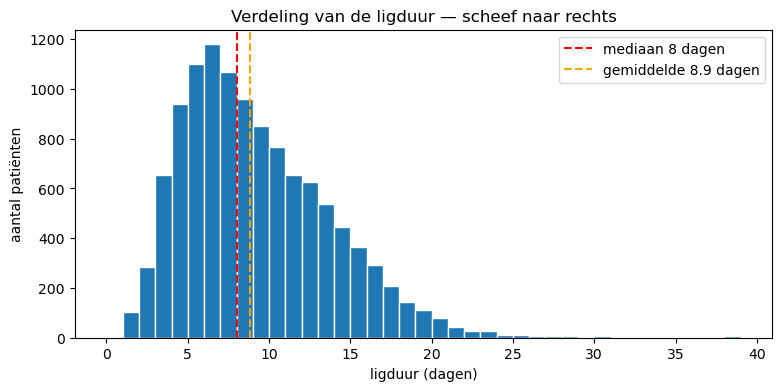

In [3]:
print(df["actual_los"].describe().round(2).to_string())
print()
print("kleinste ligduur:", df["actual_los"].min())
print("aantal opnames met ligduur <= 0:", (df["actual_los"] <= 0).sum(), " (moet 0 zijn voor LogNormal)")

plt.figure(figsize=(9, 4))
plt.hist(df["actual_los"], bins=range(0, 40), edgecolor="white")
plt.axvline(df["actual_los"].median(), color="red", linestyle="--",
            label=f"mediaan {df['actual_los'].median():.0f} dagen")
plt.axvline(df["actual_los"].mean(), color="orange", linestyle="--",
            label=f"gemiddelde {df['actual_los'].mean():.1f} dagen")
plt.xlabel("ligduur (dagen)")
plt.ylabel("aantal patiënten")
plt.title("Verdeling van de ligduur — scheef naar rechts")
plt.legend()
plt.show()

## 2.4 — Welke kolommen mag het model zien?

Dit is de belangrijkste cel van het notebook, en de plek waar een model stilletjes
waardeloos wordt als je niet oplet.

**`LEAKY` — informatie van na het ontslag.** Deze kolommen zijn pas bekend *nadat*
de patiënt weg is. `discharge_notes` beschrijft hoe de opname verliep;
`dis_complicated` is daaruit afgeleid. Zou het model die mogen gebruiken, dan krijg
je schitterende scores die in de praktijk niets waard zijn: op de ochtend dat je wilt
voorspellen, bestaat die informatie nog niet. Dit heet *lekkage* en het is de meest
voorkomende manier waarop een model beter lijkt dan het is.

`has_discharge_notes` zit er ook bij: die zegt of er een ontslagnotitie *bestaat*,
en dat is bij opname nog niet bekend.

**`NON_FEATURES` — geen signaal bij opname.** Identificatienummers (patiënt, arts,
kamer, bed) zeggen niets over ligduur; als het model er iets in vindt, is dat toeval.
`admission_notes` is vrije tekst — de bruikbare inhoud zit al in `adm_acute`.
`diagnosis_description` en `primary_diagnosis_code` zijn weggelaten omdat
`diagnosis_category` en de benchmark dezelfde informatie dragen, zonder 36 losse kolommen.
`insurance_provider` is er bewust uit gehaald: verzekeraar hoort klinisch niet mee te wegen.

**`CATEGORICAL` — tekstkolommen die getallen moeten worden.** Een model rekent met
getallen, niet met woorden. `pd.get_dummies` maakt van een kolom met waarden
E/P/T drie kolommen met 0 en 1. Dat heet one-hot encoding.

In [4]:
TARGET = "actual_los"
GROUP = "patient_id"

# Pas bekend ná ontslag — zou de uitkomst laten lekken.
LEAKY = [
    "discharge_date",
    "discharge_reason",
    "discharge_notes",
    "dis_complicated",
    "dis_to_facility",
    "has_discharge_notes",
]

# Identificatie, vrije tekst en administratie: geen signaal bij opname.
NON_FEATURES = [
    "patient_id",
    "attending_physician_id",
    "room_number",
    "bed_number",
    "insurance_provider",
    "admission_notes",
    "secondary_diagnosis_codes",
    "admission_date",
    "year",
    "diagnosis_description",
    "primary_diagnosis_code",
]

CATEGORICAL = ["sex", "adm_type", "diagnosis_category"]

drop = [c for c in LEAKY + NON_FEATURES if c in df.columns]
X = df.drop(columns=drop + [TARGET])
X = pd.get_dummies(X, columns=[c for c in CATEGORICAL if c in X.columns],
                   drop_first=False, dtype=float).astype(float)

y = df[TARGET].astype(float)
groups = df[GROUP]
benchmark = df["typical_los_benchmark"]

print(f"weggelaten: {len(drop)} kolommen")
print(f"overgebleven voorspellers: {X.shape[1]}")
print()
print(X.columns.tolist())

weggelaten: 17 kolommen
overgebleven voorspellers: 32

['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'temperature', 'typical_los_benchmark', 'n_secondary', 'sec_cardiovascular', 'sec_gastrointestinal', 'sec_infectious', 'sec_metabolic', 'sec_neurological', 'sec_other', 'sec_renal', 'sec_respiratory', 'bmi_missing', 'temperature_missing', 'adm_acute', 'sex_F', 'sex_M', 'adm_type_E', 'adm_type_P', 'adm_type_T', 'diagnosis_category_Cardiovascular', 'diagnosis_category_Gastrointestinal', 'diagnosis_category_Infectious', 'diagnosis_category_Metabolic', 'diagnosis_category_Neurological', 'diagnosis_category_Other', 'diagnosis_category_Renal', 'diagnosis_category_Respiratory']


## 2.5 — Splitsen in train, validatie en test

We verdelen de data in drie stukken, elk met een eigen rol:

| Blok | Aandeel | Waarvoor |
|---|---|---|
| **train** | 64% | hiervan leert het model |
| **validatie** | 16% | bepaalt wanneer het model moet stoppen met leren |
| **test** | 20% | het eindrapport — deze ziet het model nooit tijdens het leren |

**Waarom drie en niet twee?** Het model stopt met bijleren zodra het op de
validatieset niet meer beter wordt (*early stopping*). Maar dan is die validatieset
gebruikt om een keuze te maken, en is hij niet meer onbevooroordeeld. De testset
blijft daarom volledig buiten beeld tot het allerlaatste moment.

**Waarom `GroupShuffleSplit` en niet gewoon willekeurig?** 325 patiënten in deze data
hebben twee opnames. Belandt opname 1 in train en opname 2 in test, dan heeft het
model die patiënt al gezien en lijkt het beter dan het is. `GroupShuffleSplit` met
`groups=patient_id` houdt alle opnames van één patiënt in hetzelfde blok.

De cel controleert dat expliciet: de overlap moet overal 0 zijn.

In [5]:
TEST_SIZE = 0.20      # aandeel test
VAL_SIZE = 0.20       # aandeel van het trainblok dat validatie wordt
RANDOM_STATE = 42     # vaste waarde = iedereen krijgt dezelfde split

# Eerste knip: test eraf.
outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(outer.split(X, y, groups=groups))

# Tweede knip: van wat overblijft de validatieset eraf.
inner = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_STATE)
rel_train_idx, rel_val_idx = next(
    inner.split(X.iloc[trainval_idx], y.iloc[trainval_idx], groups=groups.iloc[trainval_idx])
)
train_idx = trainval_idx[rel_train_idx]
val_idx = trainval_idx[rel_val_idx]

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

print(f"train {len(train_idx)} | validatie {len(val_idx)} | test {len(test_idx)}")
print()
for a, b, naam in [(train_idx, val_idx, "train/validatie"),
                   (train_idx, test_idx, "train/test"),
                   (val_idx, test_idx, "validatie/test")]:
    overlap = len(set(groups.iloc[a]) & set(groups.iloc[b]))
    print(f"  patiënten in beide blokken ({naam}): {overlap}   <- moet 0 zijn")

train 7040 | validatie 1760 | test 2750

  patiënten in beide blokken (train/validatie): 0   <- moet 0 zijn
  patiënten in beide blokken (train/test): 0   <- moet 0 zijn
  patiënten in beide blokken (validatie/test): 0   <- moet 0 zijn


## 2.6 — Het model instellen

Hier staat elke knop expliciet in de code, ook de knoppen die je zou kunnen weglaten.
Dat is bewust: wat niet in de code staat, staat op een verborgen standaardwaarde, en
dan kan de groep er niet over beslissen.

**Door de groep vastgelegd:**

- `Dist=LogNormal` — de vorm van de verdeling per patiënt
- `Score=LogScore` — waarop het model wordt afgerekend tijdens het leren
- `n_estimators=500` — het maximum aantal bomen
- `learning_rate=0.01` — hoe groot de stapjes zijn; klein = voorzichtig leren

**Door mij ingevuld, aanpasbaar:**

- `minibatch_frac=1.0` — elke boom ziet alle trainingsrijen (lager = sneller, ruiziger)
- `col_sample=1.0` — elke boom ziet alle kolommen (lager = meer variatie tussen bomen)
- `natural_gradient=True` — de wiskundig nettere manier om stapjes te zetten
- `early_stopping_rounds=50` — stop als de validatiescore 50 bomen lang niet verbetert
- `random_state=42` — zorgt dat je bij herhaling dezelfde uitkomst krijgt
- `verbose_eval=50` — druk elke 50 bomen een regel af, zodat je de voortgang ziet

Wil de groep iets anders, dan is dit de cel om in te wijzigen.

In [6]:
N_ESTIMATORS = 500          # design: vastgelegd door de groep
LEARNING_RATE = 0.01        # design: vastgelegd door de groep
MINIBATCH_FRAC = 1.0
COL_SAMPLE = 1.0
NATURAL_GRADIENT = True
EARLY_STOPPING_ROUNDS = 50
VERBOSE_EVAL = 50

model = NGBRegressor(
    Dist=LogNormal,
    Score=LogScore,
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    minibatch_frac=MINIBATCH_FRAC,
    col_sample=COL_SAMPLE,
    natural_gradient=NATURAL_GRADIENT,
    verbose=True,
    verbose_eval=VERBOSE_EVAL,
    random_state=RANDOM_STATE,
)
print(model)

NGBRegressor(Dist=<class 'ngboost.distns.distn.Distn.uncensor.<locals>.DistWithUncensoredScore'>,
             random_state=RandomState(MT19937) at 0x1D959BED540,
             verbose_eval=50)


## 2.7 — Trainen

Nu gaat het model leren. Dit duurt een paar minuten — tijd voor koffie.

Wat je langs ziet komen: per 50 bomen een regel met `loss` (hoe goed het model op de
trainingsdata past) en `val_loss` (hoe goed op de validatieset). **Die tweede is de
eerlijke.** Zolang `val_loss` daalt, leert het model nog iets echts bij. Gaat `val_loss`
weer omhoog terwijl `loss` blijft dalen, dan gaat het model de trainingsdata uit zijn
hoofd leren in plaats van er patronen uit te halen — dat heet overfitting, en daarvoor
is de early stopping er.

Onderaan staat bij welke boom het model het best was op de validatieset. Is dat getal
bijna gelijk aan `n_estimators`, dan was het model nog niet uitgeleerd toen de bomen
op waren — dan is verhogen van `n_estimators` zinvol.

In [7]:
model.fit(
    X_train, y_train,
    X_val=X_val, Y_val=y_val,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
)

best = model.best_val_loss_itr
print(f"\nbeste iteratie op de validatieset: {best} van {N_ESTIMATORS}")
if best is not None and best >= N_ESTIMATORS - 1:
    print("LET OP: het model was nog niet uitgeleerd. Overweeg n_estimators te verhogen.")

[iter 0] loss=2.9023 val_loss=2.8815 scale=1.0000 norm=0.7270


[iter 50] loss=2.6696 val_loss=2.6547 scale=1.0000 norm=0.5953


[iter 100] loss=2.5331 val_loss=2.5192 scale=1.0000 norm=0.5628


[iter 150] loss=2.4007 val_loss=2.3860 scale=2.0000 norm=1.1048


[iter 200] loss=2.2921 val_loss=2.2808 scale=2.0000 norm=1.1100


...

[iter 300] loss=2.1502 val_loss=2.1594 scale=2.0000 norm=1.1492


[iter 350] loss=2.1073 val_loss=2.1313 scale=2.0000 norm=1.1658


[iter 400] loss=2.0778 val_loss=2.1146 scale=1.0000 norm=0.5868


[iter 450] loss=2.0586 val_loss=2.1038 scale=1.0000 norm=0.5909



beste iteratie op de validatieset: 499 van 500
LET OP: het model was nog niet uitgeleerd. Overweeg n_estimators te verhogen.


## 2.8 — Voorspellen op de testset

`pred_dist` geeft geen getal terug maar een **verdeling per patiënt**. Daar kun je
vervolgens van alles uit halen:

- `dist.mean()` — het gemiddelde: de puntvoorspelling
- `dist.dist.ppf(q)` — het kwantiel: bij `q=0.9` de dag waarop 90% weg is
- `dist.dist.cdf(t)` — de kans dat de ligduur **t dagen of korter** is

Die laatste is waar het de afdeling om gaat: `cdf(2)` is de kans dat deze patiënt
binnen twee dagen ontslagen is.

`max_iter=best` zorgt dat we het model gebruiken zoals het was op zijn beste moment,
niet zoals het na alle 500 bomen was.

In [8]:
dist = model.pred_dist(X_test, max_iter=best)

print("type:", type(dist).__name__)
print(f"aantal voorspelde verdelingen: {len(dist.mean())}")
print()
print("Eerste patiënt in de testset:")
print(f"  werkelijke ligduur : {y_test.iloc[0]:.0f} dagen")
print(f"  voorspeld gemiddeld: {dist.mean()[0]:.2f} dagen")
print(f"  10%-kwantiel       : {dist.dist.ppf(0.10)[0]:.2f} dagen")
print(f"  mediaan            : {dist.dist.ppf(0.50)[0]:.2f} dagen")
print(f"  90%-kwantiel       : {dist.dist.ppf(0.90)[0]:.2f} dagen")
print(f"  kans ontslag <= 7d : {dist.dist.cdf(7)[0]:.1%}")

type: DistWithUncensoredScore
aantal voorspelde verdelingen: 2750

Eerste patiënt in de testset:
  werkelijke ligduur : 11 dagen
  voorspeld gemiddeld: 9.35 dagen
  10%-kwantiel       : 7.02 dagen
  mediaan            : 9.15 dagen
  90%-kwantiel       : 11.94 dagen
  kans ontslag <= 7d : 9.8%


## 2.9 — Hoe goed is het? De scores

Vijf maten, elk met een eigen vraag:

- **MAE** (mean absolute error) — hoeveel dagen zit het model er gemiddeld naast,
  ongeacht de richting. Dit is de maat waarop stap 1 de benchmark afrekende, dus
  hiermee vergelijken we.
- **RMSE** — zelfde idee, maar grote fouten tellen zwaarder mee.
- **Dekking 10–90%** — van alle patiënten, welk deel viel echt binnen het voorspelde
  interval? Bij een eerlijk 10–90%-interval hoort **80%**. Komt er meer uit, dan zijn
  de intervallen te breed (te voorzichtig); minder, dan te smal (te stellig).
- **NLL** — de score waarop het model zelf is getraind. Alleen bruikbaar om modellen
  onderling te vergelijken.

En twee ijkpunten om tegen af te zetten: de **nationale benchmark** (de huidige
praktijk) en **"geef iedereen de mediaan"** (de domst mogelijke voorspelling).
Een model dat die twee niet verslaat, voegt niets toe.

In [9]:
y_true = y_test.to_numpy()
bench_test = benchmark.iloc[test_idx].to_numpy()

mean_pred = dist.mean()
median_pred = dist.dist.ppf(0.50)
q10 = dist.dist.ppf(0.10)
q90 = dist.dist.ppf(0.90)

scores = {
    "MAE (gemiddelde)": np.abs(mean_pred - y_true).mean(),
    "MAE (mediaan)": np.abs(median_pred - y_true).mean(),
    "RMSE": np.sqrt(((mean_pred - y_true) ** 2).mean()),
    "dekking 10-90% (ideaal 0.80)": ((y_true >= q10) & (y_true <= q90)).mean(),
    "gemiddelde NLL": -dist.logpdf(y_true).mean(),
    "MAE nationale benchmark": np.abs(bench_test - y_true).mean(),
    "MAE iedereen de mediaan": np.abs(np.median(y_true) - y_true).mean(),
}

for naam, waarde in scores.items():
    print(f"{naam:32s} {waarde:.3f}")

MAE (gemiddelde)                 1.506
MAE (mediaan)                    1.504
RMSE                             2.706
dekking 10-90% (ideaal 0.80)     0.873
gemiddelde NLL                   2.073
MAE nationale benchmark          3.714
MAE iedereen de mediaan          3.611


## 2.10 — Wat vindt het model belangrijk?

`feature_importances_` geeft per voorspeller hoeveel het model hem gebruikt heeft.
De `[0]` pakt de eerste parameter van de verdeling (het midden); met `[1]` zie je
welke kolommen de *spreiding* bepalen — dus bij welke patiënten het model onzeker is.

Dit is nadrukkelijk **geen oorzaak-gevolg**. Dat een kolom bovenaan staat, betekent
dat het model er voorspelkracht in vond, niet dat hij de ligduur veroorzaakt.

                        voorspeller  belang_midden  belang_spreiding
              typical_los_benchmark         0.3106            0.3063
                        n_secondary         0.1271            0.0814
                                age         0.1171            0.1578
                          adm_acute         0.0913            0.0758
                         adm_type_P         0.0673            0.0595
       diagnosis_category_Metabolic         0.0545            0.0096
           diagnosis_category_Renal         0.0510            0.0056
diagnosis_category_Gastrointestinal         0.0456            0.0051
  diagnosis_category_Cardiovascular         0.0309            0.0358
           diagnosis_category_Other         0.0262            0.0034
     diagnosis_category_Respiratory         0.0230            0.0026
    diagnosis_category_Neurological         0.0212            0.0000
                       diastolic_bp         0.0117            0.0632
                                bm

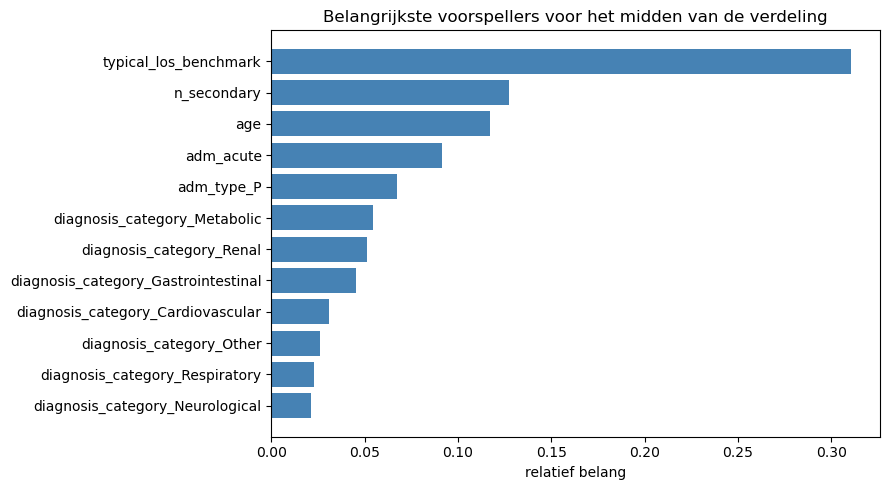

In [10]:
belang = (pd.DataFrame({"voorspeller": X.columns,
                        "belang_midden": model.feature_importances_[0],
                        "belang_spreiding": model.feature_importances_[1]})
            .sort_values("belang_midden", ascending=False))

belang.head(15).round(4).to_string(index=False)
print(belang.head(15).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
top = belang.head(12).iloc[::-1]
ax.barh(top["voorspeller"], top["belang_midden"], color="steelblue")
ax.set_xlabel("relatief belang")
ax.set_title("Belangrijkste voorspellers voor het midden van de verdeling")
plt.tight_layout()
plt.show()

## 2.11 — Zijn de voorspelde verdelingen te vertrouwen?

De MAE zegt of het midden klopt. Deze cel controleert of de **onzekerheid** klopt,
en dat is voor bedplanning minstens zo belangrijk: een model dat systematisch te
zeker is, laat de afdeling op te weinig bedden rekenen.

De methode: voor een reeks kwantielen kijken we welk deel van de patiënten er
werkelijk onder viel. Voorspelt het model het 30%-kwantiel goed, dan zou ongeveer
30% van de patiënten daaronder moeten zitten. Ligt de lijn op de diagonaal, dan is
het model goed gekalibreerd. Ligt hij eronder, dan zijn de voorspellingen te hoog;
erboven, te laag.

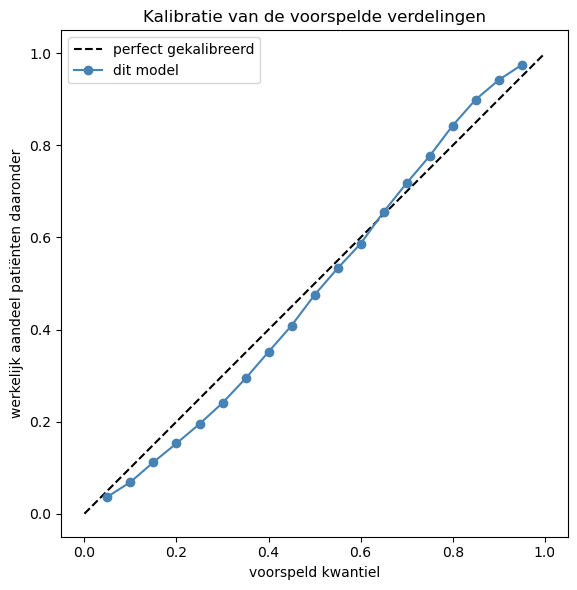

dekking 10-90%: 87.3%  (ideaal 80%)


In [11]:
kwantielen = np.arange(0.05, 1.00, 0.05)
waargenomen = [(y_true <= dist.dist.ppf(q)).mean() for q in kwantielen]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="perfect gekalibreerd")
ax.plot(kwantielen, waargenomen, "o-", color="steelblue", label="dit model")
ax.set_xlabel("voorspeld kwantiel")
ax.set_ylabel("werkelijk aandeel patiënten daaronder")
ax.set_title("Kalibratie van de voorspelde verdelingen")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"dekking 10-90%: {((y_true >= q10) & (y_true <= q90)).mean():.1%}  (ideaal 80%)")

## 2.12 — De voorspellingen wegschrijven

Tot slot bouwen we de tabel waar de afdeling mee verder kan. Per patiënt:

- `ln_mu` en `ln_sigma` — de twee opgeslagen parameters van de verdeling. Daarmee kun
  je later elke gewenste kans opnieuw uitrekenen zonder het model te hoeven draaien.
- `pred_mean`, `q10`, `q50`, `q90` — punt­voorspelling en onzekerheidsband
- `p_los_le_Xd` — de kans op ontslag binnen X dagen; dit is de kolomreeks voor de
  dagelijkse bedplanning

Eén technisch punt: `dist.params` geeft de parameters in de notatie van scipy
(`s` = sigma, `scale` = exp(mu)). We rekenen dat om naar de leesbare mu en sigma.

In [12]:
HORIZONS = [1, 2, 3, 5, 7, 10, 14]
QUANTILES = [0.10, 0.50, 0.90]

params = dist.params    # scipy-notatie: s = sigma, scale = exp(mu)

out = pd.DataFrame({
    "patient_id": df[GROUP].iloc[test_idx].to_numpy(),
    "actual_los": y_true,
    "pred_mean": mean_pred,
    "ln_mu": np.log(params["scale"]),
    "ln_sigma": params["s"],
})
for q in QUANTILES:
    out[f"q{int(q * 100):02d}"] = dist.dist.ppf(q)
for t in HORIZONS:
    out[f"p_los_le_{t}d"] = dist.dist.cdf(t)

out_path = OUT_DIR / "los_predictions_test_v2.csv"
out.to_csv(out_path, index=False)
print(f"weggeschreven: {len(out)} patiënten naar {out_path.name}")

out.head(10).round(3)

weggeschreven: 2750 patiënten naar los_predictions_test_v2.csv


,patient_id,actual_los,pred_mean,ln_mu,ln_sigma,q10,q50,q90,p_los_le_1d,p_los_le_2d,p_los_le_3d,p_los_le_5d,p_los_le_7d,p_los_le_10d,p_los_le_14d
0,PAT-04784,11.0,9.352,2.214,0.208,7.015,9.153,11.941,0.0,0.000,0.000,0.002,0.098,0.665,0.980
1,PAT-07071,9.0,10.692,2.346,0.218,7.893,10.440,13.809,0.0,0.000,0.000,0.000,0.033,0.422,0.911
2,PAT-09839,6.0,8.749,2.133,0.267,6.000,8.444,11.883,0.0,0.000,0.000,0.025,0.241,0.737,0.971
3,PAT-01434,6.0,6.840,1.890,0.256,4.769,6.620,9.190,0.0,0.000,0.001,0.136,0.586,0.946,0.998
4,PAT-07283,6.0,7.069,1.917,0.277,4.769,6.803,9.704,0.0,0.000,0.002,0.133,0.541,0.918,0.995
5,PAT-05129,12.0,9.983,2.281,0.199,7.588,9.788,12.627,0.0,0.000,0.000,0.000,0.046,0.543,0.964
6,PAT-02406,13.0,10.202,2.301,0.206,7.667,9.987,13.010,0.0,0.000,0.000,0.000,0.042,0.502,0.949
7,PAT-08179,4.0,5.246,1.605,0.323,3.291,4.979,7.535,0.0,0.002,0.058,0.505,0.854,0.985,0.999
8,PAT-01209,9.0,8.684,2.136,0.224,6.352,8.468,11.289,0.0,0.000,0.000,0.009,0.198,0.771,0.987
9,PAT-01714,16.0,15.062,2.691,0.205,11.347,14.750,19.174,0.0,0.000,0.000,0.000,0.000,0.029,0.399


## 2.13 — Wat dit betekent voor de bedplanning

Deze laatste cel maakt de vertaalslag naar de vraag van de afdeling. Tel je per
horizon de kansen op over alle patiënten, dan krijg je het **verwachte aantal
ontslagen** binnen zoveel dagen.

De optelsom van kansen is precies het verwachte aantal — dat is wiskundig correct,
ook al is geen enkele patiënt afzonderlijk zeker. Daarnaast tonen we wat er
werkelijk gebeurde, zodat je ziet of de schatting klopt.

Dit is een terugblik op de testset, geen live voorspelling. Voor de patiënten die
nú liggen (`current_patients_v2.csv`) moet hetzelfde model op die tabel worden
toegepast — dat is stap 3.

In [13]:
overzicht = pd.DataFrame({
    "horizon (dagen)": HORIZONS,
    "verwacht aantal ontslagen": [out[f"p_los_le_{t}d"].sum() for t in HORIZONS],
    "werkelijk aantal ontslagen": [(y_true <= t).sum() for t in HORIZONS],
})
overzicht["verschil"] = (overzicht["verwacht aantal ontslagen"]
                         - overzicht["werkelijk aantal ontslagen"])
print(f"testset: {len(out)} patiënten\n")
print(overzicht.round(1).to_string(index=False))

testset: 2750 patiënten

 horizon (dagen)  verwacht aantal ontslagen  werkelijk aantal ontslagen  verschil
               1                        5.6                          20     -14.4
               2                       46.9                          82     -35.1
               3                      150.8                         250     -99.2
               5                      573.4                         737    -163.6
               7                     1123.0                        1266    -143.0
              10                     1824.0                        1880     -56.0
              14                     2416.0                        2437     -21.0


## Samenvatting

Wat dit notebook heeft opgeleverd:

1. Een NGBoost-model dat per patiënt een LogNormal-verdeling over de ligduur geeft
2. Een testset-score die je kunt afzetten tegen de nationale benchmark uit stap 1
3. Een kalibratiecontrole: kloppen de onzekerheidsmarges, of is het model te stellig?
4. `Output/los_predictions_test_v2.csv` met per patiënt de ontslagkans per horizon

**Aandachtspunten voor de groep:**

- Staat er bij 2.7 dat het model nog niet uitgeleerd was, dan is `n_estimators`
  verhogen (naar bijvoorbeeld 2000) de eerste verbetering om te proberen. Dat is een
  design-beslissing, want 500 is door de groep vastgelegd.
- `typical_los_benchmark` is de sterkste voorspeller. Verdedigbaar, want bij opname
  bekend — maar het betekent wel dat het model deels de benchmark corrigeert in
  plaats van los daarvan te voorspellen. Wil de groep weten hoe het model het
  zónder doet, dan is dat één regel in cel 2.4.
- De testset is hier eenmalig gebruikt. Wordt hij vaker gebruikt om keuzes te maken,
  dan verliest hij zijn waarde als onafhankelijk eindoordeel.

---

# Deel 2 — Van totale ligduur naar "gaat deze patiënt morgen naar huis?"

Alles hierboven voorspelt de **totale** ligduur, gezien vanaf de opnamedag. Dat is
een voorspelling die je één keer maakt, bij binnenkomst.

De afdeling heeft iets anders nodig. Op een willekeurige ochtend ligt er een patiënt
die er al 6 dagen is, en de vraag is: **gaat die morgen weg?** Het feit dat hij die
6 dagen gehaald heeft, is informatie — het sluit alle uitkomsten onder de 6 dagen uit.

Het goede nieuws: daarvoor hoeft het model niet opnieuw getraind te worden. De
verdeling per patiënt bevat het antwoord al; we moeten hem alleen bijwerken voor wat
we inmiddels weten.

## 2.14 — De voorwaardelijke ontslagkans

De formule, in woorden: van de kans die nog "over" is, welk deel valt op morgen?

$$P(\text{ontslag morgen} \mid \text{al } d \text{ dagen opgenomen}) =
\frac{P(LOS \le d+1) - P(LOS \le d)}{1 - P(LOS \le d)}$$

- De **teller** is de kans dat het ontslag precies in het komende etmaal valt.
- De **noemer** is de kans dat de patiënt er vandaag nog ligt. Delen door dat getal
  is het bijwerken: we gooien alle scenario's weg waarin hij al vertrokken zou zijn.

Deze grootheid heet de **hazard**. Merk op dat hij stijgt naarmate iemand langer
ligt, ook al verandert het model niet — de resterende mogelijkheden worden minder.

De functie hieronder werkt met de twee opgeslagen parameters, dus je hebt het
getrainde model er niet meer voor nodig.

In [14]:
from scipy.stats import norm


def cdf_lognormal(t, ln_mu, ln_sigma):
    """P(LOS <= t) voor een LogNormal met parameters ln_mu en ln_sigma."""
    t = np.asarray(t, dtype=float)
    return norm.cdf((np.log(t) - ln_mu) / ln_sigma)


def kans_ontslag_binnen(ln_mu, ln_sigma, dagen_opgenomen, horizon=1):
    """Kans op ontslag binnen `horizon` dagen, gegeven dat de patient er al ligt.

    Geeft NaN terug wanneer de restkans verwaarloosbaar is: het model acht het dan
    vrijwel uitgesloten dat de patient nu nog ligt, en de uitkomst is onbetrouwbaar.
    """
    d = np.asarray(dagen_opgenomen, dtype=float)
    nu = cdf_lognormal(d, ln_mu, ln_sigma)
    straks = cdf_lognormal(d + horizon, ln_mu, ln_sigma)
    restkans = 1.0 - nu
    with np.errstate(divide="ignore", invalid="ignore"):
        hazard = (straks - nu) / restkans
    return np.where(restkans < 1e-6, np.nan, hazard)


# Controle op de eerste patient uit de testset.
_p = out.iloc[0]
print(f"patient {_p.patient_id}, voorspelde mediaan {np.exp(_p.ln_mu):.1f} dagen, "
      f"werkelijk {_p.actual_los:.0f} dagen\n")
print(" al opgenomen | P(LOS<=d) | kans ontslag morgen")
print(" -------------|-----------|--------------------")
for dd in [1, 3, 5, 7, 9, 11, 14]:
    print(f"   dag {dd:2d}      |   {cdf_lognormal(dd, _p.ln_mu, _p.ln_sigma):5.1%}   |"
          f"      {kans_ontslag_binnen(_p.ln_mu, _p.ln_sigma, dd):6.1%}")

patient PAT-04784, voorspelde mediaan 9.2 dagen, werkelijk 11 dagen

 al opgenomen | P(LOS<=d) | kans ontslag morgen
 -------------|-----------|--------------------
   dag  1      |    0.0%   |        0.0%
   dag  3      |    0.0%   |        0.0%
   dag  5      |    0.2%   |        1.9%
   dag  7      |    9.8%   |       17.8%
   dag  9      |   46.8%   |       37.1%
   dag 11      |   81.2%   |       48.9%
   dag 14      |   98.0%   |       57.4%


## 2.15 — Klopt die kans ook echt?

Een formule die mooi oploopt is nog geen bewijs. Deze cel controleert het op de
testset, waar we de werkelijke ligduur kennen.

De methode: neem alle patiënten die dag *d* gehaald hebben, tel op wat het model als
ontslagkans voor de volgende dag gaf, en vergelijk dat met hoeveel er werkelijk
vertrokken. Staan die twee kolommen dicht bij elkaar, dan is de voorwaardelijke kans
bruikbaar.

Let op de kolom `n`: hoe verder in de opname, hoe minder patiënten er nog liggen, en
hoe ruiziger de vergelijking wordt. De laatste regels berusten op weinig gevallen.

 dag    n  voorspelde kans  werkelijke kans  verschil
   1 2730            0.014            0.023    -0.009
   2 2668            0.035            0.063    -0.028
   3 2500            0.059            0.086    -0.027
   4 2285            0.084            0.119    -0.035
   5 2013            0.103            0.141    -0.038
   6 1730            0.116            0.142    -0.026
   7 1484            0.130            0.143    -0.013
   8 1272            0.146            0.167    -0.022
   9 1059            0.159            0.178    -0.019
  10  870            0.176            0.178    -0.003
  11  715            0.198            0.208    -0.011
  12  566            0.220            0.217     0.002
  13  443            0.243            0.293    -0.051
  14  313            0.270            0.284    -0.014
  15  224            0.291            0.326    -0.035
  16  151            0.313            0.305     0.009
  17  105            0.335            0.343    -0.008
  18   69            0.370  

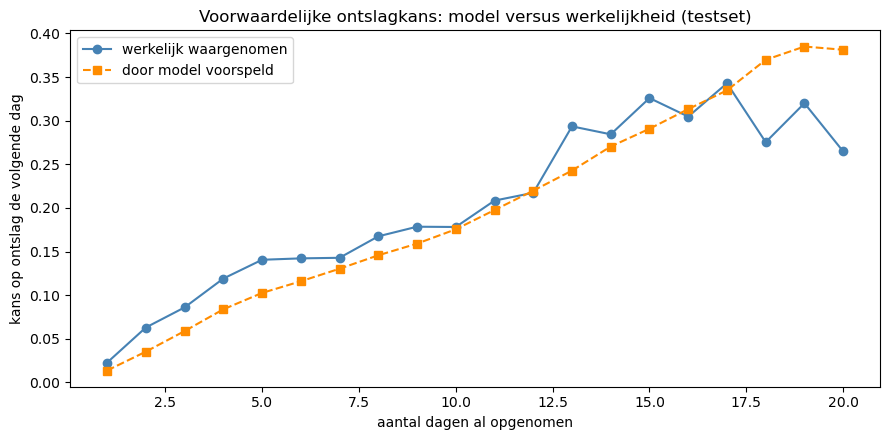

In [15]:
rijen = []
for d in range(1, 21):
    nog_aanwezig = out["actual_los"] > d          # patienten die dag d gehaald hebben
    n = int(nog_aanwezig.sum())
    if n < 25:                                     # te weinig om iets van te vinden
        continue
    blok = out[nog_aanwezig]
    voorspeld = kans_ontslag_binnen(blok["ln_mu"].to_numpy(),
                                    blok["ln_sigma"].to_numpy(), d)
    werkelijk = (blok["actual_los"] <= d + 1).mean()
    rijen.append({"dag": d, "n": n,
                  "voorspelde kans": np.nanmean(voorspeld),
                  "werkelijke kans": werkelijk})

controle = pd.DataFrame(rijen)
controle["verschil"] = controle["voorspelde kans"] - controle["werkelijke kans"]
print(controle.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(controle["dag"], controle["werkelijke kans"], "o-", color="steelblue",
        label="werkelijk waargenomen")
ax.plot(controle["dag"], controle["voorspelde kans"], "s--", color="darkorange",
        label="door model voorspeld")
ax.set_xlabel("aantal dagen al opgenomen")
ax.set_ylabel("kans op ontslag de volgende dag")
ax.set_title("Voorwaardelijke ontslagkans: model versus werkelijkheid (testset)")
ax.legend()
plt.tight_layout()
plt.show()

## 2.16 — De huidige patiënten klaarmaken

Nu de echte toepassing: de 32 patiënten die vandaag op de afdeling liggen.

`current_patients_v2.csv` is **ruwe data** — de afgeleide kolommen die de historie wel
heeft (`n_secondary`, `adm_acute`, de `sec_*`-vlaggen, de diagnose-koppeling) zitten er
niet in. Die moeten we op precies dezelfde manier aanmaken, anders herkent het model
de kolommen niet.

Twee dingen die hier anders zijn dan bij de historie:

- Er is **geen ontslagnotitie**, want deze mensen liggen er nog. Alle kolommen die
  daaruit waren afgeleid, hebben we bij het trainen al weggelaten — dat komt nu goed uit.
- `days_admitted` is de kolom die we straks gebruiken om de kans bij te werken. Hij
  gaat **niet** het model in als voorspeller: het model is getraind op wat er bij
  opname bekend was, en `days_admitted` hoort daar niet bij.

Aan het eind controleren we of de kolommen exact overeenkomen met de trainingsdata.

In [16]:
curr = pd.read_csv(ROOT / "Data" / "current_patients_v2.csv")
lookup = pd.read_csv(ROOT / "Data" / "diagnosis_lookup_v2.csv", dtype=str)
lookup["typical_los_benchmark"] = pd.to_numeric(lookup["typical_los_benchmark"])

print(f"huidige patiënten: {len(curr)}")
print(f"dagen al opgenomen: {curr['days_admitted'].min()} t/m {curr['days_admitted'].max()}"
      f" (mediaan {curr['days_admitted'].median():.0f})")

# --- diagnose-koppeling, net als in de data-prep ---
curr = curr.merge(lookup[["icd_code", "diagnosis_category", "typical_los_benchmark"]],
                  left_on="primary_diagnosis_code", right_on="icd_code",
                  how="left").drop(columns="icd_code")
assert curr["diagnosis_category"].notna().all(), "onbekende diagnosecode"

# --- secundaire diagnoses: aantal en categorie-vlaggen ---
code2cat = dict(zip(lookup["icd_code"].str.strip(),
                    lookup["diagnosis_category"].str.strip()))
CATEGORIEEN = sorted(set(code2cat.values()))

sec_tekst = curr["secondary_diagnosis_codes"].fillna("")
curr["n_secondary"] = sec_tekst.apply(lambda s: len([c for c in s.split(";") if c.strip()]))
sec_cats = sec_tekst.str.split(";").apply(
    lambda codes: {code2cat[c.strip()] for c in codes if c.strip()})
for cat in CATEGORIEEN:
    curr[f"sec_{cat.lower()}"] = sec_cats.apply(lambda s, c=cat: int(c in s))

# --- ontbrekende metingen: vlag + invullen met de mediaan van de historie ---
for c in ["bmi", "temperature"]:
    curr[f"{c}_missing"] = curr[c].isna().astype(int)
for c in ["bmi", "systolic_bp", "diastolic_bp", "heart_rate", "temperature"]:
    curr[c] = pd.to_numeric(curr[c], errors="coerce").fillna(df[c].median())

# --- opnamenotitie: acuut of stabiel ---
ACUTE_MARKERS = ["High-acuity", "visibly unwell", "distressed state",
                 "immediate stabilisation", "evident distress", "Complex presentation"]
notities = curr["admission_notes"].fillna("")
curr["adm_acute"] = notities.str.contains("|".join(ACUTE_MARKERS)).astype(float)
curr.loc[curr["admission_notes"].isna(), "adm_acute"] = np.nan

print("\nafgeleide kolommen aangemaakt")

huidige patiënten: 32
dagen al opgenomen: 1 t/m 26 (mediaan 5)

afgeleide kolommen aangemaakt


### De kolommen gelijktrekken

Het model verwacht exact dezelfde kolommen in exact dezelfde volgorde als tijdens het
trainen. Twee dingen kunnen misgaan:

- een categorie die bij de huidige patiënten **niet voorkomt** (bijvoorbeeld geen
  enkele neurologische diagnose) levert een ontbrekende kolom op
- een categorie die alleen hier voorkomt levert een kolom te veel op

`reindex` lost beide op: ontbrekende kolommen worden aangemaakt met 0, overtollige
verdwijnen. De `assert` controleert dat het gelukt is — draait die zonder klacht door,
dan is de invoer precies wat het model verwacht.

In [17]:
X_curr = pd.get_dummies(curr, columns=[c for c in CATEGORICAL if c in curr.columns],
                        drop_first=False, dtype=float)
X_curr = X_curr.reindex(columns=X.columns, fill_value=0.0).astype(float)

assert list(X_curr.columns) == list(X.columns), "kolommen wijken af van de trainingsdata"
print(f"invoer klaar: {X_curr.shape[0]} patiënten x {X_curr.shape[1]} voorspellers")
print("kolommen identiek aan trainingsdata: ja")

invoer klaar: 32 patiënten x 32 voorspellers
kolommen identiek aan trainingsdata: ja


## 2.17 — De ontslagkansen voor vandaag

Nu komt alles samen. Per patiënt:

1. het model voorspelt de verdeling over de **totale** ligduur
2. we werken die bij met het aantal dagen dat hij al ligt
3. dat geeft de kans op ontslag binnen 1, 2 en 3 dagen — vanaf vandaag gerekend

`verwachte_resterende_dagen` is de mediaan van de bijgewerkte verdeling min de dagen
die al verstreken zijn: de beste schatting van hoeveel dagen er nog te gaan zijn.

Waar `NaN` staat, ligt de patiënt al veel langer dan het model voor mogelijk hield.
Die gevallen zijn niet te vertrouwen en vragen om een blik van de arts — de kolom
`let_op` markeert ze.

In [18]:
dist_curr = model.pred_dist(X_curr, max_iter=best)
params_curr = dist_curr.params
mu_curr = np.log(params_curr["scale"])
sigma_curr = params_curr["s"]
dagen = curr["days_admitted"].to_numpy(dtype=float)

vandaag = pd.DataFrame({
    "patient_id": curr["patient_id"],
    "leeftijd": curr["age"],
    "diagnose": curr["diagnosis_category"],
    "dagen_opgenomen": curr["days_admitted"],
    "voorspelde_totale_ligduur": np.exp(mu_curr).round(1),
})
for h, naam in [(1, "kans_ontslag_morgen"), (2, "kans_binnen_2d"), (3, "kans_binnen_3d")]:
    vandaag[naam] = kans_ontslag_binnen(mu_curr, sigma_curr, dagen, horizon=h)

# Mediaan van de bijgewerkte verdeling: de dag waarop de helft vertrokken is.
rest_kans = 1.0 - cdf_lognormal(dagen, mu_curr, sigma_curr)
with np.errstate(divide="ignore", invalid="ignore"):
    mediaan_totaal = np.exp(mu_curr + sigma_curr * norm.ppf(1.0 - rest_kans / 2.0))
vandaag["verwachte_resterende_dagen"] = np.where(
    rest_kans < 1e-6, np.nan, np.maximum(mediaan_totaal - dagen, 0.0))

vandaag["let_op"] = np.where(vandaag["kans_ontslag_morgen"].isna(),
                             "ligt langer dan model voorzag", "")

vandaag = vandaag.sort_values("kans_ontslag_morgen", ascending=False, na_position="last")
pad = OUT_DIR / "ontslagkans_huidige_patienten_v2.csv"
vandaag.to_csv(pad, index=False)
print(f"weggeschreven naar {pad.name}\n")

weergave = vandaag.copy()
for c in ["kans_ontslag_morgen", "kans_binnen_2d", "kans_binnen_3d"]:
    weergave[c] = (weergave[c] * 100).round(1)
print(weergave.round(1).to_string(index=False))

weggeschreven naar ontslagkans_huidige_patienten_v2.csv

patient_id  leeftijd         diagnose  dagen_opgenomen  voorspelde_totale_ligduur  kans_ontslag_morgen  kans_binnen_2d  kans_binnen_3d  verwachte_resterende_dagen let_op
  PAT-C013        61        Metabolic                8                        3.8                 65.6            88.1            95.8                         0.7       
  PAT-C008        98            Other               12                        4.1                 61.3            84.8            93.9                         0.7       
  PAT-C004        58 Gastrointestinal               18                       10.0                 54.7            79.7            91.0                         0.9       
  PAT-C010        68            Other                5                        5.1                 47.6            76.5            90.5                         1.1       
  PAT-C029        63 Gastrointestinal               10                        8.4            

## 2.18 — Hoeveel bedden komen er morgen vrij?

De vertaalslag naar de vraag waar het allemaal om begon.

Tel je de individuele ontslagkansen op, dan krijg je het **verwachte aantal** ontslagen.
Dat is wiskundig correct, ook al is geen enkele patiënt afzonderlijk zeker.

Daarnaast geven we een marge. Als de patiënten min of meer onafhankelijk van elkaar
vertrekken, is de spreiding rond dat aantal te berekenen als de wortel van de som van
`p × (1−p)`. De band van plus en min twee keer die spreiding is het realistische
bereik — bruikbaarder voor de planning dan één getal.

De aanname van onafhankelijkheid is een vereenvoudiging: gaat de hele afdeling op
vrijdag dicht of loopt er een uitbraak, dan hangen de ontslagen wél samen. Voor een
ochtendoverzicht is de benadering redelijk, maar houd hem in het achterhoofd.

afdeling: 32 patiënten, waarvan 0 buiten modelbereik

 binnen (dagen)  verwacht aantal ontslagen  ondergrens  bovengrens
              1                        7.8           4          12
              2                       13.8           9          18
              3                       18.3          14          23


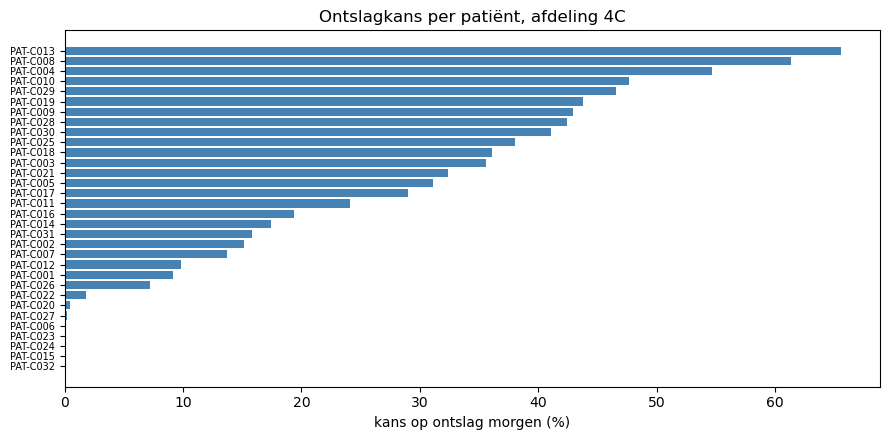

In [19]:
overzicht = []
for h, naam in [(1, "kans_ontslag_morgen"), (2, "kans_binnen_2d"), (3, "kans_binnen_3d")]:
    p = vandaag[naam].dropna().to_numpy()
    verwacht = p.sum()
    spreiding = np.sqrt((p * (1 - p)).sum())
    overzicht.append({
        "binnen (dagen)": h,
        "verwacht aantal ontslagen": round(verwacht, 1),
        "ondergrens": max(0, round(verwacht - 2 * spreiding)),
        "bovengrens": round(verwacht + 2 * spreiding),
    })

print(f"afdeling: {len(vandaag)} patiënten, "
      f"waarvan {int(vandaag['kans_ontslag_morgen'].isna().sum())} buiten modelbereik\n")
print(pd.DataFrame(overzicht).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
kans = vandaag["kans_ontslag_morgen"].dropna().sort_values()
ax.barh(range(len(kans)), kans * 100, color="steelblue")
ax.set_yticks(range(len(kans)))
ax.set_yticklabels(vandaag.loc[kans.index, "patient_id"], fontsize=7)
ax.set_xlabel("kans op ontslag morgen (%)")
ax.set_title("Ontslagkans per patiënt, afdeling 4C")
plt.tight_layout()
plt.show()

## Samenvatting deel 2

Wat route A heeft opgeleverd:

1. Een functie die de ontslagkans bijwerkt met het aantal dagen dat iemand al ligt —
   zonder het model opnieuw te trainen
2. Een controle op de testset: komt de voorspelde kans overeen met wat er werkelijk gebeurde?
3. `Output/ontslagkans_huidige_patienten_v2.csv` met per patiënt de ontslagkans voor
   morgen, over 2 en over 3 dagen
4. Een verwacht aantal vrijkomende bedden, met marge

**Wat dit model nog niet kan:**

- Het weet alleen wat er **bij opname** bekend was. Verslechtert een patiënt op dag 4,
  dan ziet het model dat niet — de voorspelling verandert alleen doordat de tijd verstrijkt.
- De patiënten met `let_op` liggen langer dan het model voor mogelijk hield. Juist die
  gevallen zijn voor de planning het lastigst, en daar is het model het minst bruikbaar.
- De kalibratie uit 2.11 (banden te breed) werkt door in deze kansen. Sectie 2.15 laat
  zien hoe erg dat in de praktijk uitpakt.

Route B — het model trainen op dagelijkse waarnemingen, met `days_admitted` als
voorspeller — lost het eerste en tweede punt op. Dat is een aparte opzet en een
beslissing voor de groep.